# Where does the population go? Per-m leakage map of the RID 76695 symmetric MZ

This notebook projects the atom onto the momentum/internal-state basis **after
every pulse** of the genuine ARTIQ RID 76695 symmetric Mach-Zehnder
(`DeclarativeLMTGlobalSymmetricMachZehnderFrag`) and plots the resulting
populations, so we can see exactly where population leaks out of the intended
interferometer path as the sequence progresses.

**Readout convention.** The "probability of finding the atom in `(m, internal)`
if we projected right now" is the sim's own projective-measurement quantity,
`calculate_ground_and_excited_probabilities`: for each momentum class `m` the
amplitudes of all rows sharing `(m, internal)` are summed **coherently** and
squared,

$$P_\text{g}(m) = \Bigl|\sum_{\text{rows: }m,\,g} c\Bigr|^2, \qquad
  P_\text{e}(m) = \Bigl|\sum_{\text{rows: }m,\,e} c\Bigr|^2 .$$

This is frame-independent (all rows of one `(m, internal)` carry the same
Bordé-frame phase) and it is what a real clearout / detection would measure.
Because it is coherent, these populations genuinely reflect interference
between paths that recombine into the same `m`.

**Interferometry phase.** Set to **zero** here (`interferometer_phase = 0`):
pulses 10-18 would otherwise carry `φ` and pulse 19 `4φ` (the scanned MZ
phase), but for a *leakage* diagnostic the zero-phase configuration is the
clean baseline. Only the final recombination (last couple of pulses) depends
on the scan phase; the leakage during the mirror train does not.

**No clearouts.** The raw pulse sequence is run with no 461 nm clearouts, so
every bit of leaked population stays visible instead of being thrown away --
that is the point of the diagnostic.

In [1]:
import sys

sys.path.insert(0, "..")

import warnings
import dataclasses

import numpy as np
import matplotlib.pyplot as plt

import lmt_sim.lmt_sequence as seq
import lmt_sim.lmt_simulation as sim

## The RID 76695 pulse dump (interferometer_phase = 0 point)

Genuine float64 SI `pulse_record_flat` as emitted by `PulseDMARecording`. The
8th row (per-pulse interferometry phase) is all zeros at this scan point.

In [2]:
pulse_record_flat = np.array([
    20.0, 1.0, 0.0, 1.0, 1.0, 0.0,
    0.0, 0.0, 0.0, 1.0, 1.0, 0.0,
    1.0, 1.0, 0.0, 0.0, 0.0, 0.0,
    1.0, 1.0, 0.0, 0.0011392000000000002, 0.002142592, 0.002231312,
    0.0025090480000000003, 0.0026367680000000003, 0.0027254880000000003, 0.002864208, 0.0031529440000000004, 0.003291664,
    0.003369384, 0.0034496320000000002, 0.0035383520000000003, 0.003816088, 0.003943808, 0.0040325280000000005,
    0.004171248000000001, 0.004459984, 0.004598704, 0.004676424, 0.004756672, 0.000379999,
    6.7e-05, 5.5999000000000004e-05, 5.5999000000000004e-05, 6.7e-05, 6.7e-05, 6.7e-05,
    6.7e-05, 5.5999000000000004e-05, 5.5999000000000004e-05, 6.7e-05, 5.5999000000000004e-05, 5.5999000000000004e-05,
    6.7e-05, 6.7e-05, 6.7e-05, 6.7e-05, 5.5999000000000004e-05, 5.5999000000000004e-05,
    6.7e-05, 80014038.33602092, 79984442.05274647, 80009610.08426937, 80032313.77748647, 79996307.57957408,
    79957453.70680287, 79993114.16819608, 79951451.93554893, 80024498.14328054, 80044393.47662166, 79966090.32742324,
    80027961.8095926, 80050665.50280967, 79977955.85425085, 79939101.98147964, 79974762.44287285, 79933100.2102257,
    80042849.86860377, 80062745.20194489, 79947738.60210001, 200000000.0, 200000000.0, 200000000.0,
    200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0,
    200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0,
    200000000.0, 200000000.0, 200000000.0, 200000000.0, 200000000.0, 99426200.0,
    99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0,
    99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0,
    99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0, 99426200.0,
    99426200.0, 0.012, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
])
pulse_record_offsets = np.array([0], dtype=np.int64)

dump = seq.decode_pulse_record_flat(pulse_record_flat, pulse_record_offsets)[0]
n_pulses = len(dump.is_up)
print(f"decoded {n_pulses} pulses; up/down = {dump.is_up.sum()}/{(~dump.is_up).sum()}")

decoded 20 pulses; up/down = 9/11


## Build the sequence (calibrated, phase = 0, no clearouts)

`calibrate_probe_shift_and_velocity_from_dump` reverse-engineers the AC-Stark
coefficient and initial velocity that put every recorded pulse on its intended
recoil rung (a self-consistent fit -- it warns loudly; suppressed here for
readability). The build then folds the free-fall Doppler shift into the
recorded detunings, so the quantum run is done at v = 0.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    alpha, v0 = seq.calibrate_probe_shift_and_velocity_from_dump(
        **dataclasses.asdict(dump)
    )
print(f"probe-shift alpha = {alpha:.4g} 1/Hz   initial velocity = {v0 * 1e3:+.3f} mm/s")

_timestamps, sequence = seq.build_sequence_from_lab_pulse_dump(
    **dataclasses.asdict(dump),
    probe_induced_alpha_up=alpha,
    probe_induced_alpha_down=alpha,
    initial_velocity_z=v0,
)
pulse_events = [e for e in sequence if isinstance(e, seq.Pulse)]
assert len(pulse_events) == n_pulses

probe-shift alpha = -1.708e-05 1/Hz   initial velocity = -0.034 mm/s


## Project after every pulse

`iter_pulse_sequence_in_borde_representation` yields the state before the first
event and after every event. We keep the snapshot taken immediately after each
`Pulse` (free-fall between pulses does not change the `(m, internal)`
populations, only their phases and positions), giving one momentum spectrum per
pulse index 0..19.

In [4]:
def coherent_populations_by_m(state):
    """Return {m: P_ground(m)}, {m: P_excited(m)} using the coherent per-m sum."""
    p_ground, p_excited = {}, {}
    for m in np.unique(state.m_values):
        same_m = state.m_values == m
        g = same_m & state.internal_is_ground
        e = same_m & ~state.internal_is_ground
        p_ground[int(m)] = float(np.abs(state.amplitudes[g].sum()) ** 2)
        p_excited[int(m)] = float(np.abs(state.amplitudes[e].sum()) ** 2)
    return p_ground, p_excited


# Snapshot after every event, then keep the ones that follow a Pulse.
initial = sim.make_atom_states(c0=1, c1=0, initial_velocity_z=0.0)
snapshots = list(
    seq.iter_pulse_sequence_in_borde_representation(
        initial, sequence, initial_velocity_z=0.0, discard_threshold=1e-12
    )
)
# snapshots[0] is the initial state; snapshots[i + 1] is after sequence[i].
per_pulse_ground = []
per_pulse_excited = []
for i, event in enumerate(sequence):
    if isinstance(event, seq.Pulse):
        state = snapshots[i + 1][0]
        pg, pe = coherent_populations_by_m(state)
        per_pulse_ground.append(pg)
        per_pulse_excited.append(pe)

assert len(per_pulse_ground) == n_pulses

# Assemble dense (n_pulses x n_m) probability matrices on a shared m-grid.
all_m = sorted(
    {m for d in (per_pulse_ground + per_pulse_excited) for m in d}
)
m_index = {m: j for j, m in enumerate(all_m)}
ground_mat = np.zeros((n_pulses, len(all_m)))
excited_mat = np.zeros((n_pulses, len(all_m)))
for p in range(n_pulses):
    for m, val in per_pulse_ground[p].items():
        ground_mat[p, m_index[m]] = val
    for m, val in per_pulse_excited[p].items():
        excited_mat[p, m_index[m]] = val

total_per_pulse = ground_mat.sum(axis=1) + excited_mat.sum(axis=1)
print(f"m classes populated across the sequence: {all_m[0]} .. {all_m[-1]}")
print(f"total projected probability per pulse: min {total_per_pulse.min():.3f}, "
      f"max {total_per_pulse.max():.3f} (coherent readout conserves probability)")

m classes populated across the sequence: -5 .. 9
total projected probability per pulse: min 1.000, max 1.000 (coherent readout conserves probability)


## The leakage map -- populations by m, swept pulse by pulse

Two panels (ground, excited). **x = momentum class m, y = projection
probability.** One line per pulse, coloured from dark (early pulses) to bright
(late pulses), so you can watch population get pumped up the recoil ladder and
see where it spills into unintended classes.

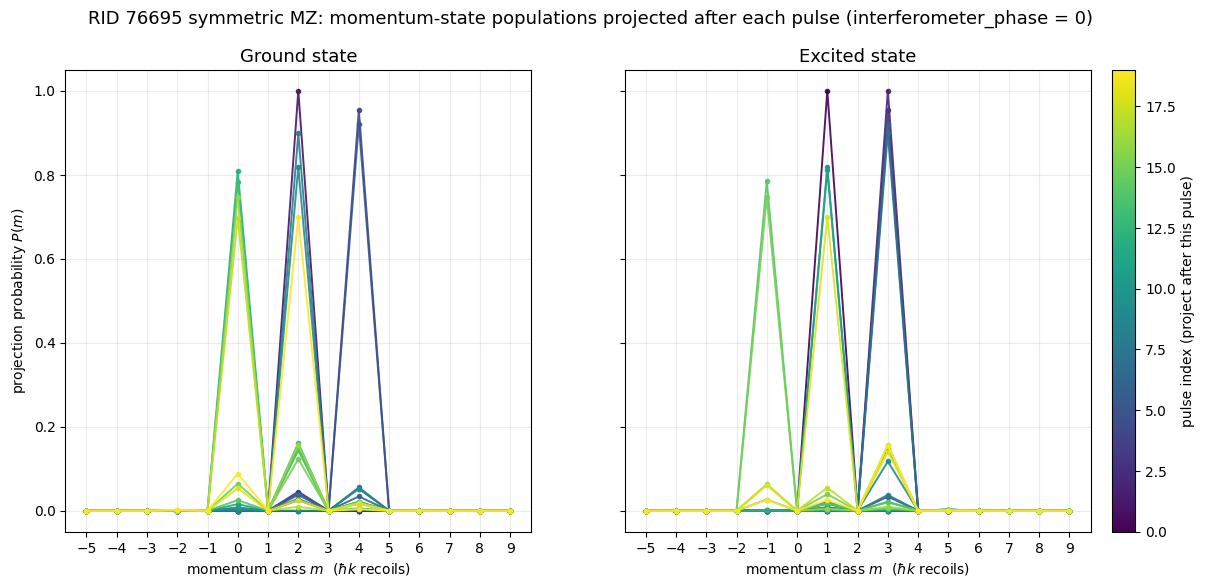

In [5]:
m_arr = np.array(all_m)
cmap = plt.get_cmap("viridis")
colors = [cmap(p / (n_pulses - 1)) for p in range(n_pulses)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, mat, title in (
    (axes[0], ground_mat, "Ground state"),
    (axes[1], excited_mat, "Excited state"),
):
    for p in range(n_pulses):
        ax.plot(m_arr, mat[p], color=colors[p], lw=1.4, marker="o", ms=3, alpha=0.9)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("momentum class $m$  ($\\hbar k$ recoils)")
    ax.grid(alpha=0.25)
    ax.set_xticks(m_arr)
axes[0].set_ylabel("projection probability $P(m)$")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n_pulses - 1))
cbar = fig.colorbar(sm, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label("pulse index (project after this pulse)")
fig.suptitle(
    "RID 76695 symmetric MZ: momentum-state populations projected after each pulse "
    "(interferometer_phase = 0)",
    fontsize=13,
)
plt.show()

## Same data as heatmaps

A complementary view: pulse index on the vertical axis, momentum on the
horizontal, colour = projection probability. Rows read top-to-bottom as the
sequence advances; bright horizontal streaks are where population parks.

The colour is on a **logarithmic** scale so the weak parasitic paths -- the
few-times-$10^{-3}$ population that off-resonant transfer spills into
unintended `m` classes -- are visible alongside the near-unity main streak. A
linear scale washes them out entirely. Probabilities below ``FLOOR`` (and the
exact zeros) are clipped to the darkest colour.

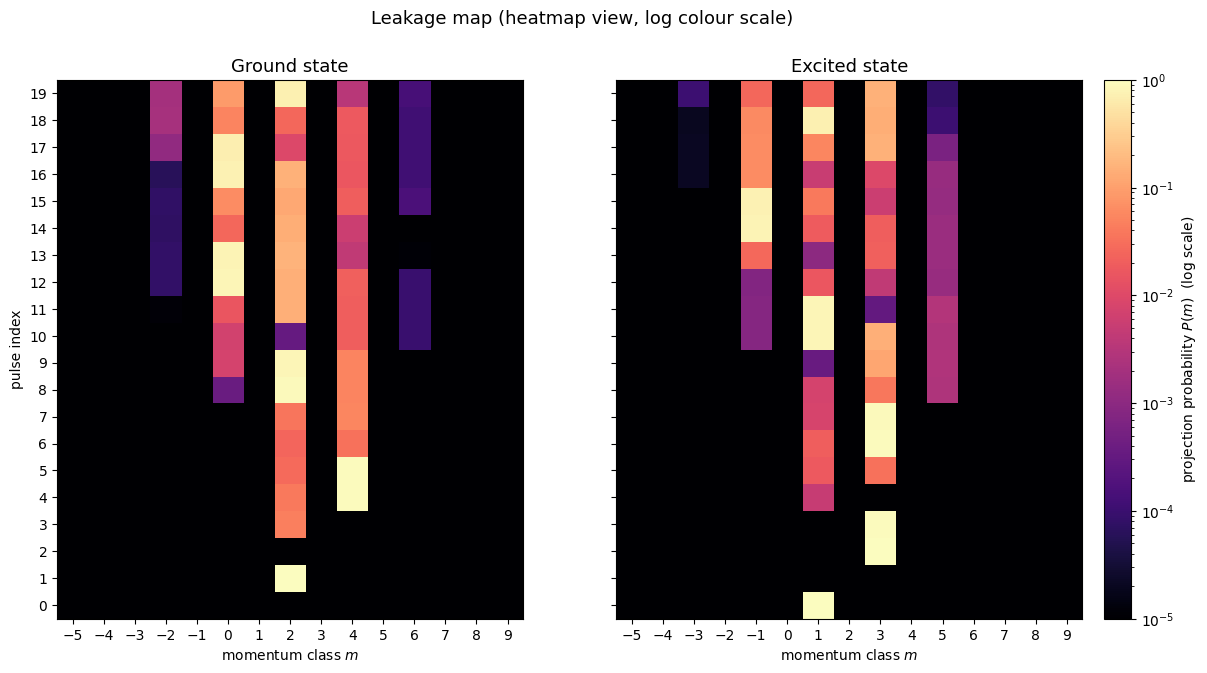

In [6]:
from matplotlib.colors import LogNorm  # noqa: E402
import matplotlib as mpl  # noqa: E402

FLOOR = 1e-5  # lower end of the log colour scale (5 decades down from ~1)
log_cmap = mpl.colormaps["magma"].copy()
log_cmap.set_bad(log_cmap(0.0))  # exact-zero cells render as the low-end colour

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
norm = LogNorm(vmin=FLOOR, vmax=1.0)
for ax, mat, title in (
    (axes[0], ground_mat, "Ground state"),
    (axes[1], excited_mat, "Excited state"),
):
    masked = np.where(mat > 0, mat, np.nan)  # keep true zeros out of the log
    im = ax.imshow(
        masked,
        aspect="auto",
        origin="lower",
        cmap=log_cmap,
        norm=norm,
        extent=[m_arr[0] - 0.5, m_arr[-1] + 0.5, -0.5, n_pulses - 0.5],
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("momentum class $m$")
    ax.set_xticks(m_arr)
axes[0].set_ylabel("pulse index")
axes[0].set_yticks(range(n_pulses))
cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label("projection probability $P(m)$  (log scale)")
fig.suptitle("Leakage map (heatmap view, log colour scale)", fontsize=13)
plt.show()

## Overall book-keeping: ground/excited split and total vs pulse

How the total ground and excited probability evolve, and confirmation that the
coherent projective readout conserves total probability (there are no clearouts
to remove any).

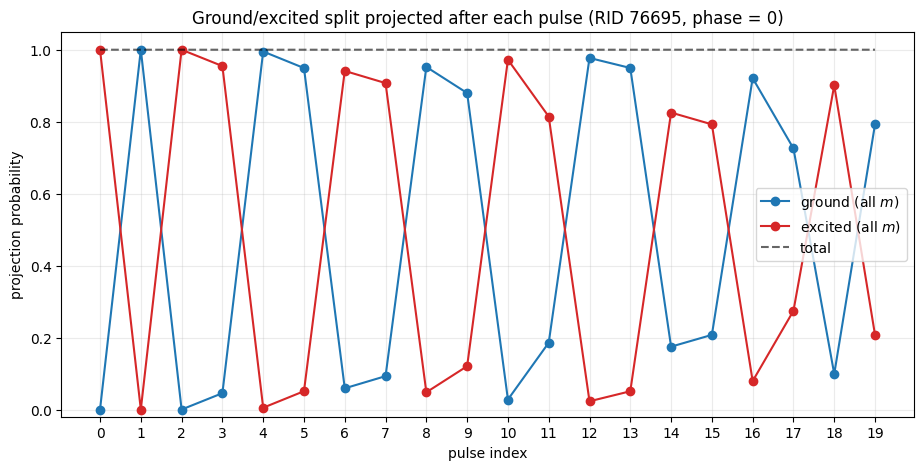

In [7]:
ground_total = ground_mat.sum(axis=1)
excited_total = excited_mat.sum(axis=1)
pulses = np.arange(n_pulses)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pulses, ground_total, "-o", label="ground (all $m$)", color="tab:blue")
ax.plot(pulses, excited_total, "-o", label="excited (all $m$)", color="tab:red")
ax.plot(pulses, total_per_pulse, "--", label="total", color="k", alpha=0.6)
ax.set_xlabel("pulse index")
ax.set_ylabel("projection probability")
ax.set_xticks(pulses)
ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.25)
ax.legend()
ax.set_title("Ground/excited split projected after each pulse (RID 76695, phase = 0)")
plt.show()

### Reading the map

* Pulse 0 is the 380 us velocity-selection pulse: it drives the selected slice
  from `|g, 0>` to `|e, +1>`, so straight after it the population sits almost
  entirely in the `m = +1` excited class.
* The launch ladder then walks the packet up in momentum; the excited/ground
  alternation is visible as population hops between adjacent `m` on each pulse.
* Any probability that appears in an `m` the intended path never visits is
  **leakage** -- off-resonant transfer that a perfect sequence would not
  produce. Those are the streaks to scrutinise.

Because the interferometry phase is zero here, the final-pulse recombination
lands in one particular set of ports; sweeping the scan phase (pulses 10-18
get `φ`, pulse 19 gets `4φ`) redistributes population **only among the
recombining classes** and leaves this leakage picture otherwise unchanged.